In [2]:
import torch
from torch.distributions import MultivariateNormal, Categorical, MixtureSameFamily
import zuko
import matplotlib.pyplot as plt
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam


/root/phd/GW_seperation_analysis/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# import sys
# !{sys.executable} -m pip install zuko

In [ ]:
# we start with a 4 d problem, get 2, 2d gaussians,
# Use normalizing flows from U[0,1] distr to the gaussian, these are the quantiles
d_1 = 2
d_2 = 2
flow_1 = zuko.flows.spline.NSF(
    features=d_1,  #dim of the output
    transforms=8,
)
dist_1 = flow_1()
T_1    = dist_1.transform

flow_2 = zuko.flows.spline.NSF(
    features=d_2,  #dim of the output
    transforms=8,
)
dist_2 = flow_2()
T_2    = dist_2.transform

def sampleGaussianBase(params,N):
    # Covariance matrix (identity) #correlated
    d           = params["d"]
    sqrtSigma   = torch.linalg.cholesky(params["Sigma"])
    chi2        = torch.distributions.Chi2(df=d)
    chi_samples = torch.sqrt(chi2.sample((N,)))

    Z           = torch.randn(N, d)
    U_samples   = Z / torch.norm(Z, dim=1, keepdim=True)
    res         = chi_samples*(sqrtSigma @ U_samples.T)
    return res

def InvTransport(params,res,indx):
    Sigma   = params["Sigma"]
    S       = torch.linalg.cholesky(Sigma[indx,indx])
    dist    = torch.distributions.Normal(loc=0, scale=1)
    Transf  = S.T @ res[indx,:]
    blocks  = []
    for i in range(indx.stop - indx.start):
        blocks.append(dist.cdf(Transf[i,:]).unsqueeze(0))
    Z = torch.cat(blocks, dim=0)
    return Z.T

def sampleVectorCopula(params,N):
    res = sampleGaussianBase(params,N)
    Z_1 = InvTransport(params, res, slice(0, 2))
    Z_2 = InvTransport(params, res, slice(2, 4))
    return Z_1,Z_2

def sampleVectorCopulaModel(params,N):
    Z_1,Z_2 = sampleVectorCopula(params,N)
    dist    = torch.distributions.Normal(loc=0, scale=1)
    sample_1 = T_1(dist.cdf(Z_1)) #can be used because they are independent
    sample_2 = T_2(dist.cdf(Z_2))
    return torch.cat([sample_1,sample_2], dim=1).T

def logProbCopula(params,theta):
    dist            = torch.distributions.Normal(loc=0, scale=1)
    Sigma           = params['Sigma']
    _, logabsdet    = torch.linalg.slogdet(Sigma)
    SigmaInv        = torch.linalg.inv(Sigma)
    PhiInv          = dist.icdf(theta)
    einsum = torch.einsum("ni,ij,nj->n", PhiInv, (SigmaInv - torch.eye(params["d"])), PhiInv)  #sum in order to deal with quadratic form dimensions
    logDensity = (-1/2)*logabsdet+(-1/2)*einsum
    return logDensity

def logProbVectorCopula(params,theta):
    dist    = torch.distributions.Normal(loc=0, scale=1)
    U_1 = dist.cdf(T_1.inv(theta[:,0:2]))
    U_2 = dist.cdf(T_2.inv(theta[:,2:4]))
    U   = torch.concat([U_1,U_2],dim = 1)
    logp_marg_1 = dist_1.log_prob(U[:,0:2])
    logp_marg_2 = dist_2.log_prob(U[:,2:4])
    logDensity = logProbCopula(params,U)
    return logp_marg_1 + logp_marg_2 + logDensity
    

In [ ]:
theta = torch.randn(10,4)
# theta
Z = logProbVectorCopula(params,theta)
Z

In [ ]:
# Distribution object
# dist = torch.distributions.MultivariateNormal(mu, covariance_matrix=Sigma)
def plotMarg(Z,d = 4):
    X_np = Z.detach().cpu().numpy()
    plt.figure()
    plt.scatter(X_np[0,:], X_np[1,:], s=d)
    plt.xlabel("x0")
    plt.ylabel("x1")
    plt.show()
plotMarg(Z[0:2,:])
plotMarg(Z[2:4,:])   
    

In [ ]:
### custom 4d distribution, mixture of 3 guassians with different correlation structure -> multimodal and one can tune the connection
weights = torch.tensor([0.4, 0.4,0.2])

# Means (2 components × 4 dimensions)
means = torch.tensor([
    [0., 0., 0., 0.],
    [2., 2., 2., 2.],
    [4., 0., 0., 4.]
])

Sigma1 = torch.tensor([
    [1.0, 0.8, 0.2, 0.0],
    [0.8, 1.0, 0.3, 0.15],
    [0.2, 0.3, 1.0, 0.4],
    [0.0, 0.15, 0.4, 1.0]
])

Sigma2 = torch.tensor([
    [1.0, 0.0, 0.4, 0.3],
    [0.0, 1.0, 0.1, 0.25],
    [0.4, 0.1, 1.0, 0.0],
    [0.3, 0.25, 0.0, 1.0]
])

Sigma3 = torch.tensor([
    [1.0, -0.35, 0.2, 0.6],
    [-0.35, 1.0, -0.1, 0.15],
    [0.2, -0.1, 1.0, 0.0],
    [0.6, 0.15, 0.0, 1.0]
])

# Covariances (3 × 4 × 4)
covs = torch.stack([
    Sigma1,
    Sigma2,
    Sigma3
])

params_true_data = {
        "covs" : covs,
        "means" : means,
        "weights" : weights
        }
# components = MultivariateNormal(loc=params_true_data['means'], covariance_matrix=params_true_data['covs'])
# mixture = MixtureSameFamily(mix, params_true_data['weights'])
# samp_mix = mixture.sample((10000,))
# plotMarg(samp_mix.T[0:2,:])

In [ ]:
N      = 1000
params = {
    "d" : 4,
    "Sigma" : torch.tensor([
        [1.0, 0.8, 0.2, 0.0],
        [0.8, 1.0, 0.3, 0.15],
        [0.2, 0.3, 1.0, 0.4],
        [0.0, 0.15, 0.4, 1.0]
    ]),
    "S_1"    : torch.diag(torch.tensor([1.0,1.0])),
    "S_2"    : torch.diag(torch.tensor([1.0,1.0])),
    "loc_1"  : torch.tensor([0.0,0.0]),
    "loc_2"  : torch.tensor([0.0,0.0]),
    "eta_1"  : 1,
    "eta_2"  : 1,
    "L_1"    : torch.tensor([
        [1.0, 0.0],
        [0.8, 1.0],
    ]),
    "L_2"    : torch.tensor([
        [1.0, 0.0],
        [0.6, 1.0],
    ])
}
Z = sampleVectorCopula(params,N)

In [ ]:
# add constraints
def model(params,X):
    N = X.shape[0]
    with pyro.plate("data", N):
        z = pyro.sample("z", dist.Categorical(probs=params['weights']),
                        infer={"enumerate": "parallel"}) 
        pyro.sample("x", dist.MultivariateNormal(params['means'][z], params['covs'][z]),obs = X)

def guide(params,X):
    for name, value in params.items():
        pyro.param(name, value.clone())
    
    U = sample()

# variational approx"
# generate from copula
# use normalizing flow to push forward



svi = SVI(model, guide, Adam({"lr": 1e-2}), loss=Trace_ELBO())

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


def _corr_to_cov(R: np.ndarray, std=None):
    R = np.asarray(R, dtype=float)
    if R.shape != (2, 2):
        raise ValueError("R must be 2x2.")
    if not np.allclose(R, R.T):
        raise ValueError("R must be symmetric.")
    if np.linalg.det(R) <= 0:
        raise ValueError("R must be positive definite.")

    if std is None:
        std = np.ones(2)

    std = np.asarray(std)
    D = np.diag(std)

    return D @ R @ D


def plot_gaussian_and_copula_scatter(
    R,
    n=4000,
    std=None,
    seed=0,
):
    """
    Plot only scatterplots for
      (1) 2D Gaussian data
      (2) the associated Gaussian copula
    """

    rng = np.random.default_rng(seed)

    # ---- Gaussian data ----
    Sigma = _corr_to_cov(R, std)
    X = rng.multivariate_normal(
        mean=np.zeros(2),
        cov=Sigma,
        size=n
    )

    # ---- Gaussian copula ----
    Z = rng.multivariate_normal(
        mean=np.zeros(2),
        cov=R,
        size=n
    )

    U = norm.cdf(Z)

    # ---- Plot ----
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].scatter(X[:, 0], X[:, 1], s=5, alpha=0.4)
    axes[0].set_title("2D Gaussian samples")
    axes[0].set_xlabel("$x_1$")
    axes[0].set_ylabel("$x_2$")
    axes[0].grid(True)

    axes[1].scatter(U[:, 0], U[:, 1], s=5, alpha=0.4)
    axes[1].set_title("Gaussian copula samples")
    axes[1].set_xlabel("$u_1$")
    axes[1].set_ylabel("$u_2$")
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1)
    axes[1].set_aspect("equal")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

    return X, U

rho = 0.0
R = np.array([
    [1.0, rho],
    [rho, 1.0]
])

plot_gaussian_and_copula_scatter(R)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal


def gaussian_copula_cdf_grid(R, gridsize=100, eps=1e-6):
    """
    Compute the 2D Gaussian copula CDF on a grid:
        C(u,v) = Phi_R(Phi^{-1}(u), Phi^{-1}(v))
    """
    R = np.asarray(R, dtype=float)

    if R.shape != (2, 2):
        raise ValueError("R must be a 2x2 matrix.")
    if not np.allclose(R, R.T):
        raise ValueError("R must be symmetric.")
    if np.linalg.det(R) <= 0:
        raise ValueError("R must be positive definite.")

    u = np.linspace(eps, 1 - eps, gridsize)
    v = np.linspace(eps, 1 - eps, gridsize)
    U, V = np.meshgrid(u, v)

    X = norm.ppf(U)
    Y = norm.ppf(V)
    pos = np.dstack((X, Y))

    mvn = multivariate_normal(mean=[0.0, 0.0], cov=R)
    C = mvn.cdf(pos)

    return U, V, C


def plot_gaussian_copula_cdf(R, gridsize=100, n_contours=12, surface=True):
    """
    Plot the 2D Gaussian copula CDF without a heatmap:
      - contour plot
      - optional 3D surface plot
    """
    U, V, C = gaussian_copula_cdf_grid(R, gridsize=gridsize)
    rho = R[0, 1]

    if surface:
        fig = plt.figure(figsize=(12, 5))

        # Contour plot
        ax1 = fig.add_subplot(1, 2, 1)
        cs = ax1.contour(U, V, C, levels=n_contours)
        ax1.clabel(cs, inline=True, fontsize=8)
        ax1.set_title(f"Gaussian copula CDF contours ($\\rho={rho:.2f}$)")
        ax1.set_xlabel("$u$")
        ax1.set_ylabel("$v$")
        ax1.set_xlim(0, 1)
        ax1.set_ylim(0, 1)
        ax1.set_aspect("equal")

        # 3D surface
        ax2 = fig.add_subplot(1, 2, 2, projection="3d")
        ax2.plot_surface(U, V, C, linewidth=0, antialiased=True)
        ax2.set_title("Gaussian copula CDF surface")
        ax2.set_xlabel("$u$")
        ax2.set_ylabel("$v$")
        ax2.set_zlabel("$C(u,v)$")

    else:
        fig, ax1 = plt.subplots(figsize=(6, 6))
        cs = ax1.contour(U, V, C, levels=n_contours)
        ax1.clabel(cs, inline=True, fontsize=8)
        ax1.set_title(f"Gaussian copula CDF contours ($\\rho={rho:.2f}$)")
        ax1.set_xlabel("$u$")
        ax1.set_ylabel("$v$")
        ax1.set_xlim(0, 1)
        ax1.set_ylim(0, 1)
        ax1.set_aspect("equal")

    plt.tight_layout()
    plt.show()

rho = -0.5
R = np.array([
    [1.0, rho],
    [rho, 1.0]
])

plot_gaussian_copula_cdf(R, gridsize=120, n_contours=12, surface=True)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, kendalltau


def sample_positive_stable(alpha, n, rng=None):
    """
    Sample from a positive alpha-stable distribution with Laplace transform
        E[exp(-t V)] = exp(-t^alpha),   alpha in (0, 1].

    Uses the Chambers-Mallows-Stuck style formula.
    """
    if not (0 < alpha <= 1):
        raise ValueError("alpha must be in (0, 1].")

    if rng is None:
        rng = np.random.default_rng()

    if alpha == 1.0:
        return np.ones(n)

    U = rng.uniform(0, np.pi, size=n)
    W = rng.exponential(scale=1.0, size=n)

    part1 = np.sin(alpha * U) / (np.sin(U) ** (1 / alpha))
    part2 = (np.sin((1 - alpha) * U) / W) ** ((1 - alpha) / alpha)

    return part1 * part2


def sample_gumbel_copula(n, theta, rng=None):
    """
    Sample n points from a 2D Gumbel copula with parameter theta >= 1.

    Returns
    -------
    U : array of shape (n, 2)
        Copula samples with uniform marginals.
    """
    if theta < 1:
        raise ValueError("Gumbel parameter theta must be >= 1.")

    if rng is None:
        rng = np.random.default_rng()

    alpha = 1.0 / theta
    V = sample_positive_stable(alpha, n, rng=rng)
    E = rng.exponential(scale=1.0, size=(n, 2))

    # Marshall-Olkin construction for Archimedean copulas
    U = np.exp(-((E / V[:, None]) ** alpha))

    return U


def gumbel_to_normal_marginals(U, mu=(0.0, 0.0), sigma=(1.0, 1.0)):
    """
    Transform copula uniforms to Gaussian marginals.
    """
    mu = np.asarray(mu, dtype=float)
    sigma = np.asarray(sigma, dtype=float)

    if mu.shape != (2,) or sigma.shape != (2,):
        raise ValueError("mu and sigma must be length-2.")

    X = norm.ppf(U)
    X = mu + sigma * X
    return X


def fit_gumbel_theta_from_data(X):
    """
    Estimate Gumbel theta from data using:
      1. pseudo-observations via ranks
      2. Kendall's tau
      3. theta = 1 / (1 - tau)

    Valid only when tau >= 0 for the Gumbel family.
    """
    X = np.asarray(X)
    if X.shape[1] != 2:
        raise ValueError("X must have shape (n, 2).")

    n = X.shape[0]

    # pseudo-observations
    ranks = np.argsort(np.argsort(X, axis=0), axis=0) + 1
    Uhat = ranks / (n + 1.0)

    tau, _ = kendalltau(Uhat[:, 0], Uhat[:, 1])

    if tau < 0:
        raise ValueError(
            f"Estimated Kendall tau is negative ({tau:.3f}). "
            "A Gumbel copula is not appropriate for negative dependence."
        )

    theta_hat = 1.0 / (1.0 - tau)
    return theta_hat, tau, Uhat


def demo_gumbel_normal_model(
    n=3000,
    theta=2.0,
    mu=(0.0, 0.0),
    sigma=(1.0, 1.5),
    seed=42
):
    rng = np.random.default_rng(seed)

    # Step 1: simulate from Gumbel copula
    U = sample_gumbel_copula(n=n, theta=theta, rng=rng)

    # Step 2: impose Gaussian marginals
    X = gumbel_to_normal_marginals(U, mu=mu, sigma=sigma)

    # Step 3: fit Gumbel parameter back from the simulated data
    theta_hat, tau_hat, Uhat = fit_gumbel_theta_from_data(X)

    print(f"True theta:      {theta:.4f}")
    print(f"Estimated tau:   {tau_hat:.4f}")
    print(f"Estimated theta: {theta_hat:.4f}")

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    axes[1].scatter(U[:, 0], U[:, 1], s=6, alpha=0.35)
    axes[1].set_title(f"Gumbel copula sample (theta={theta:.2f})")
    axes[1].set_xlabel("$u_1$")
    axes[1].set_ylabel("$u_2$")
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1)
    axes[1].set_aspect("equal")
    axes[1].grid(True, alpha=0.3)

    axes[0].scatter(X[:, 0], X[:, 1], s=6, alpha=0.35)
    axes[0].set_title("Normal marginals + Gumbel dependence")
    axes[0].set_xlabel("$x_1$")
    axes[0].set_ylabel("$x_2$")
    axes[0].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return U, X, theta_hat, tau_hat


if __name__ == "__main__":
    U, X, theta_hat, tau_hat = demo_gumbel_normal_model(
        n=4000,
        theta=2.5,
        mu=(0.0, 0.0),
        sigma=(1.0, 2.0),
        seed=123
    )

In [1]:
import toy_problem

/root/phd/GW_seperation_analysis/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== Internal consistency test ===
N train                : 10000
M eval                 : 10000
dim                    : 4
KDE bandwidth          : 0.384275
mean log_prob(model)   : -9.623588
mean log_prob(KDE)     : -5.649100
mean difference        : -3.974488
std difference         : 7.093426
median difference      : -1.384130
mean |difference|      : 4.655346
median |difference|    : 1.753779
max |difference|       : 64.600722
RMSE                   : 8.130696
corr(model, KDE)       : 0.693384


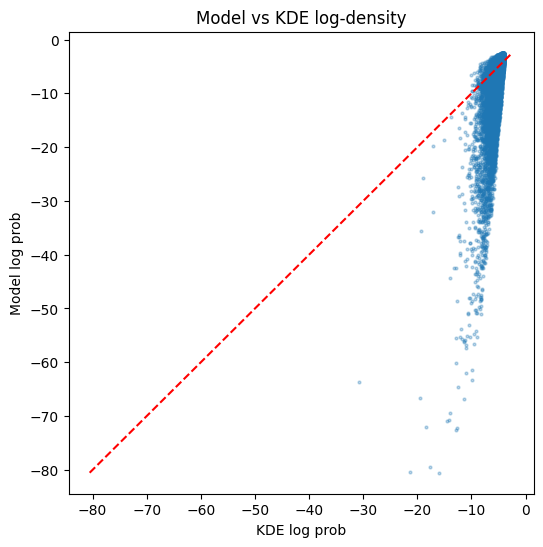

In [4]:
ModelTest = toy_problem.VectorCopulaFlowQ(toy_problem.get_params(useIdentity = False))
result = ModelTest.testInternalConsistency(10000,10000)

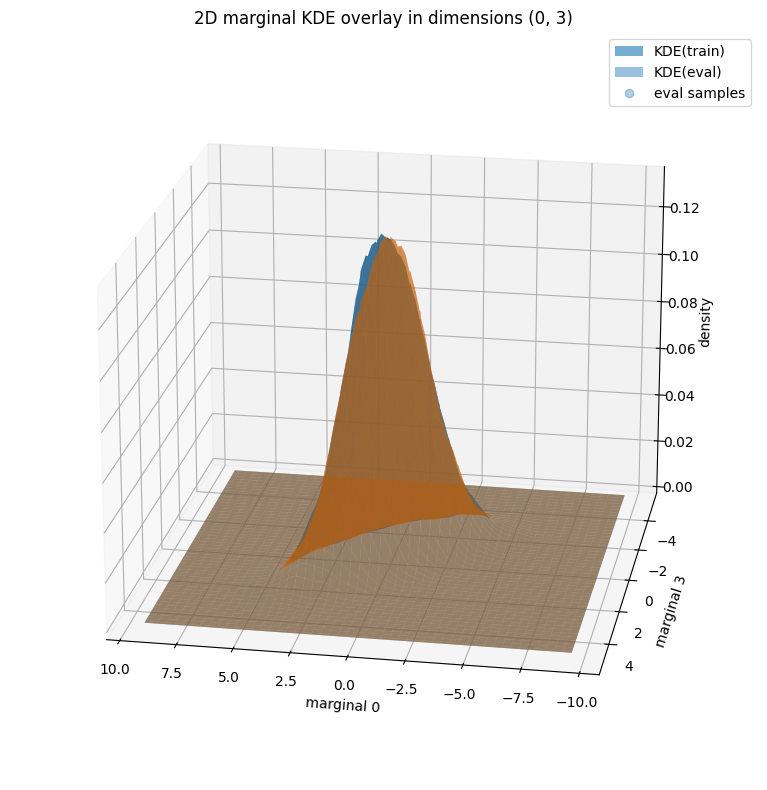

{'dims': (0, 3),
 'bandwidth_train': 0.2854395506802371,
 'bandwidth_eval': 0.2860911220263948}

In [3]:
toy_problem.plot_kde_3d_overlay_from_result(
    result,
    dims=(0, 3),                     # choose 2 of the 4 marginals
    gridsize=100,
    filename="toy_problem/kde_overlay_01.png",
    elev=20,
    azim=100
)

In [ ]:
def Blockdiag(B,dimList):
    Bdiag=B.clone()
    for dim in dimList:
        Bdiag[:dim,dim+1:] = 0
        Bdiag[dim+1:,:dim] = 0    
    return Bdiag

In [ ]:
B       = torch.ones(6,6)
dimList = [2,2,4]
Bdiag=B.clone()
prevDim=0
for dim in dimList:
    ind = dim + prevDim
    Bdiag[:ind,ind:] = 0
    Bdiag[ind:,:ind] = 0   
    prevDim = dim 


tensor([[1., 1., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [0., 0., 1., 1., 0., 0.],
        [0., 0., 1., 1., 0., 0.],
        [0., 0., 0., 0., 1., 1.],
        [0., 0., 0., 0., 1., 1.]])

In [7]:
Bdiag

tensor([[1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1.],
        [0., 0., 1., 1., 1., 1.],
        [0., 0., 1., 1., 1., 1.],
        [0., 0., 1., 1., 1., 1.]])